# Cross-Cohort Meta-Analysis
**Module 03: Pooled Effect Estimates Across Aging and Disease Cohorts**

**Method:** Random-effects meta-analysis (DerSimonian-Laird) of cell-level logistic GLMM results from Module 02, with inverse-variance weighting and heterogeneity assessment.

**Workflow:**
1. Load Module 02 GLMM results per cohort (`{dataset}_glmm_results.csv`)
2. Cell type harmonization across cohorts
3. Random-effects meta-analysis per cell type (log-odds scale)
4. Fixed-effects sensitivity analysis
5. Heterogeneity assessment (I², Cochran's Q, τ²)
6. FDR correction across cell types
7. Forest plots (cohort-level + pooled OR)
8. Summary heatmap & results export

**Input:** `Beta`, `SE` from Module 02 GLMM (OR per decade for aging, OR vs control for disease)

**Cohorts:**
- Aging: PsychAD Aging, PsychENCODE
- Disease: PsychAD AD, Mathys

**Author:** Gerald Gaitos  
**Date:** February 2026

In [1]:
# ════════════════════════════════════════════════════════════════════════════════
# IMPORTS
# ════════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.stats import chi2
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

print("✓ Packages imported")

✓ Packages imported


In [2]:
# ════════════════════════════════════════════════════════════════════════════════
# FIGURE SETTINGS
# ════════════════════════════════════════════════════════════════════════════════

import matplotlib
matplotlib.rcParams['figure.dpi'] = 300
matplotlib.rcParams['savefig.dpi'] = 300
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'Arial']
matplotlib.rcParams['font.size'] = 9
matplotlib.rcParams['axes.linewidth'] = 0.5
matplotlib.rcParams['xtick.major.width'] = 0.5
matplotlib.rcParams['ytick.major.width'] = 0.5

print("✓ Figure settings configured")
print(f"  Using font: {matplotlib.rcParams['font.sans-serif'][0]}")

✓ Figure settings configured
  Using font: DejaVu Sans


In [3]:
# ════════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════════

print("="*60)
print("CONFIGURATION")
print("="*60)

# ─────────────────────────────────────────────────────────────────────────────────
# Study Type & Paths
# ─────────────────────────────────────────────────────────────────────────────────

STUDY_TYPE = 'aging'  # Options: 'aging', 'disease'

BASE_DIR = Path('/fs/scratch/PAS2598/senescence_analysis')
INPUT_DIR = BASE_DIR / 'results' / '02_statistical_analysis'

RESULTS_DIR = BASE_DIR / 'results' / '03_meta_analysis' / STUDY_TYPE
FIGURES_DIR = BASE_DIR / 'figures' / '03_meta_analysis' / STUDY_TYPE

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────────
# Cohort Configuration
# ─────────────────────────────────────────────────────────────────────────────────
# Add/remove cohorts here. Each entry needs:
#   - key: dataset folder name (must match folder in INPUT_DIR)
#   - name: display name for plots
#   - filename: GLMM results CSV filename
#
# The input path is auto-built: INPUT_DIR / key / filename
# ─────────────────────────────────────────────────────────────────────────────────

COHORT_LIST = {
    'aging': {
        'cohorts': [
            {'key': 'psychad_aging',    'name': 'PsychAD',     'filename': 'psychad_aging_glmm_results.csv'},
            {'key': 'psychencode_sub',  'name': 'PsychENCODE', 'filename': 'psychencode_sub_glmm_results.csv'},
        ],
        'effect_label': 'OR per decade',
    },
    'disease': {
        'cohorts': [
            {'key': 'psychad_ad', 'name': 'PsychAD AD', 'filename': 'psychad_ad_glmm_results.csv'},
            {'key': 'mathys',     'name': 'Mathys',      'filename': 'mathys_glmm_results.csv'},
        ],
        'effect_label': 'OR vs Control',
    },
}

config = COHORT_LIST[STUDY_TYPE]
EFFECT_LABEL = config['effect_label']

COHORTS = {}
for c in config['cohorts']:
    COHORTS[c['key']] = {
        'name': c['name'],
        'input': INPUT_DIR / c['key'] / c['filename'],
    }

# ─────────────────────────────────────────────────────────────────────────────────
# Cell Type Harmonization
# ─────────────────────────────────────────────────────────────────────────────────

CELL_TYPE_MAP = {
    # PsychENCODE names → Harmonized
    'OPCs': 'OPC',
    'Oligodendrocytes': 'Oligodendrocyte',
    'Astrocytes': 'Astrocyte',
    'Excitatory': 'Excitatory',
    'Inhibitory': 'Inhibitory',
    'Microglia': 'Microglia',
    'Endothelial': 'Endothelial',
    'Pericyte': 'Pericyte',
    # PsychAD names (already harmonized)
    'OPC': 'OPC',
    'Oligodendrocyte': 'Oligodendrocyte',
    'Astrocyte': 'Astrocyte',
    'Microglia': 'Microglia',
    'VLMC': 'VLMC',
    'VSMC': 'VSMC',
    'PVM': 'PVM',
    'Adaptive': 'Adaptive',
}

# ─────────────────────────────────────────────────────────────────────────────────
# Module 02 GLMM Column Names
# ─────────────────────────────────────────────────────────────────────────────────

COL_CELLTYPE = 'Cell_Type'
COL_BETA = 'Beta'
COL_SE = 'SE'
COL_OR = 'OR'
COL_PVAL = 'P_value'
COL_PADJ = 'P_adj'

print(f"\n  Study type: {STUDY_TYPE}")
print(f"  Effect: {EFFECT_LABEL}")
print(f"  Cohorts:")
for key, c in COHORTS.items():
    exists = "✓" if c['input'].exists() else "✗ NOT FOUND"
    print(f"    {c['name']:<16} {exists}  ({c['input'].name})")
print(f"\n  Results: {RESULTS_DIR}")
print(f"  Figures: {FIGURES_DIR}")
print("="*60)

CONFIGURATION

  Study type: aging
  Effect: OR per decade
  Cohorts:
    PsychAD          ✓  (psychad_aging_glmm_results.csv)
    PsychENCODE      ✓  (psychencode_sub_glmm_results.csv)

  Results: /fs/scratch/PAS2598/senescence_analysis/results/03_meta_analysis/aging
  Figures: /fs/scratch/PAS2598/senescence_analysis/figures/03_meta_analysis/aging


In [4]:
# ════════════════════════════════════════════════════════════════════════════════
# LOAD DATA
# ════════════════════════════════════════════════════════════════════════════════

print("="*60)
print("LOAD DATA")
print("="*60)

cohort_data = {}

for dataset_id, cohort_info in COHORTS.items():
    filepath = cohort_info['input']
    name = cohort_info['name']
    
    print(f"\n▸ Loading: {name}")
    print(f"  Path: {filepath}")
    
    if not filepath.exists():
        print(f"  ✗ File not found — skipping")
        continue
    
    df = pd.read_csv(filepath)
    print(f"  ✓ Loaded: {len(df)} cell types")
    print(f"  Columns: {df.columns.tolist()}")
    
    # Harmonize cell type names
    df[COL_CELLTYPE] = df[COL_CELLTYPE].map(CELL_TYPE_MAP).fillna(df[COL_CELLTYPE])
    
    # Validate required columns
    required = [COL_CELLTYPE, COL_BETA, COL_SE]
    missing = [c for c in required if c not in df.columns]
    if missing:
        print(f"  ✗ Missing columns: {missing}")
        print(f"  Available: {df.columns.tolist()}")
        continue
    
    df['Cohort'] = name
    df['Dataset'] = dataset_id
    cohort_data[dataset_id] = df
    
    # Summary
    print(f"  Cell types: {df[COL_CELLTYPE].tolist()}")
    if COL_PADJ in df.columns:
        sig = df[df[COL_PADJ] < 0.05]
        print(f"  Significant (FDR<0.05): {len(sig)}")

# ─────────────────────────────────────────────────────────────────────────────────
# Identify Shared vs Single-Cohort Cell Types
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")

all_cts = {}
for dataset_id, df in cohort_data.items():
    for ct in df[COL_CELLTYPE].unique():
        if ct not in all_cts:
            all_cts[ct] = []
        all_cts[ct].append(cohort_data[dataset_id]['Cohort'].iloc[0])

shared_cts = sorted([ct for ct, cohorts in all_cts.items() if len(cohorts) > 1])
single_cts = sorted([ct for ct, cohorts in all_cts.items() if len(cohorts) == 1])

print(f"\n✓ Loaded {len(cohort_data)} cohorts")
print(f"  Shared cell types ({len(shared_cts)}): {shared_cts}")
print(f"  Single-cohort ({len(single_cts)}): {single_cts}")

# ─────────────────────────────────────────────────────────────────────────────────
# Display Input Summary Table
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("INPUT SUMMARY")
print(f"{'─'*60}")

print(f"\n{'Cell Type':<20} ", end="")
for ds_id, df in cohort_data.items():
    print(f"{'β (' + df['Cohort'].iloc[0] + ')':>16} ", end="")
print(f"{'Shared':>8}")
print("─" * (20 + 17 * len(cohort_data) + 8))

for ct in sorted(all_cts.keys()):
    print(f"{ct:<20} ", end="")
    for ds_id, df in cohort_data.items():
        ct_row = df[df[COL_CELLTYPE] == ct]
        if len(ct_row) > 0:
            beta = ct_row[COL_BETA].values[0]
            print(f"{beta:>16.4f} ", end="")
        else:
            print(f"{'—':>16} ", end="")
    shared = "★" if ct in shared_cts else ""
    print(f"{shared:>8}")

LOAD DATA

▸ Loading: PsychAD
  Path: /fs/scratch/PAS2598/senescence_analysis/results/02_statistical_analysis/psychad_aging/psychad_aging_glmm_results.csv
  ✓ Loaded: 12 cell types
  Columns: ['Cell_Type', 'N_cells', 'N_donors', 'SnC_rate', 'Beta', 'SE', 'Beta_CI_lower', 'Beta_CI_upper', 'OR', 'OR_CI_lower', 'OR_CI_upper', 'z_value', 'P_value', 'Donor_variance', 'AIC', 'P_adj', 'Significant']
  Cell types: ['PVM', 'OPC', 'Pericyte', 'Adaptive', 'VSMC', 'Astrocyte', 'VLMC', 'Inhibitory', 'Oligodendrocyte', 'Excitatory', 'Microglia', 'Endothelial']
  Significant (FDR<0.05): 3

▸ Loading: PsychENCODE
  Path: /fs/scratch/PAS2598/senescence_analysis/results/02_statistical_analysis/psychencode_sub/psychencode_sub_glmm_results.csv
  ✓ Loaded: 8 cell types
  Columns: ['Cell_Type', 'N_cells', 'N_donors', 'SnC_rate', 'Beta', 'SE', 'Beta_CI_lower', 'Beta_CI_upper', 'OR', 'OR_CI_lower', 'OR_CI_upper', 'z_value', 'P_value', 'Donor_variance', 'AIC', 'P_adj', 'Significant']
  Cell types: ['Oligodendr

In [5]:
# ════════════════════════════════════════════════════════════════════════════════
# META-ANALYSIS FUNCTIONS
# ════════════════════════════════════════════════════════════════════════════════

def meta_analysis_re(betas, ses):
    """
    Random-effects meta-analysis (DerSimonian-Laird).
    """
    betas = np.array(betas, dtype=float)
    ses = np.array(ses, dtype=float)
    k = len(betas)
    
    if k < 2:
        z = betas[0] / ses[0]
        return {
            'pooled_beta': betas[0], 'pooled_se': ses[0],
            'pooled_or': np.exp(betas[0]),
            'ci_lower_beta': betas[0] - 1.96 * ses[0],
            'ci_upper_beta': betas[0] + 1.96 * ses[0],
            'ci_lower_or': np.exp(betas[0] - 1.96 * ses[0]),
            'ci_upper_or': np.exp(betas[0] + 1.96 * ses[0]),
            'p_value': 2 * stats.norm.sf(abs(z)),
            'z_value': z,
            'I2': np.nan, 'Q': np.nan, 'Q_p': np.nan, 'tau2': np.nan,
            'k': 1, 'method': 'single_cohort',
        }
    
    w = 1.0 / ses**2
    beta_fe = np.sum(w * betas) / np.sum(w)
    
    Q = np.sum(w * (betas - beta_fe)**2)
    Q_p = 1 - chi2.cdf(Q, df=k - 1)
    I2 = max(0, (Q - (k - 1)) / Q) * 100 if Q > 0 else 0
    
    C = np.sum(w) - np.sum(w**2) / np.sum(w)
    tau2 = max(0, (Q - (k - 1)) / C)
    
    w_re = 1.0 / (ses**2 + tau2)
    pooled_beta = np.sum(w_re * betas) / np.sum(w_re)
    pooled_se = np.sqrt(1.0 / np.sum(w_re))
    z = pooled_beta / pooled_se
    p_value = 2 * stats.norm.sf(abs(z))
    
    return {
        'pooled_beta': pooled_beta, 'pooled_se': pooled_se,
        'pooled_or': np.exp(pooled_beta),
        'ci_lower_beta': pooled_beta - 1.96 * pooled_se,
        'ci_upper_beta': pooled_beta + 1.96 * pooled_se,
        'ci_lower_or': np.exp(pooled_beta - 1.96 * pooled_se),
        'ci_upper_or': np.exp(pooled_beta + 1.96 * pooled_se),
        'p_value': p_value, 'z_value': z,
        'I2': I2, 'Q': Q, 'Q_p': Q_p, 'tau2': tau2,
        'k': k, 'method': 'random_effects',
    }

print("✓ Meta-analysis functions defined")

✓ Meta-analysis functions defined


In [6]:
# ════════════════════════════════════════════════════════════════════════════════
# FILTER TO SHARED CELL TYPES
# ════════════════════════════════════════════════════════════════════════════════

print("="*60)
print("FILTER TO SHARED CELL TYPES")
print("="*60)

# Keep only cell types present in 2+ cohorts
all_ct_count = len(all_cts)
excluded_cts = sorted([ct for ct, cohorts in all_cts.items() if len(cohorts) < 2])

print(f"\n▸ Total cell types: {all_ct_count}")
print(f"  Shared (kept): {len(shared_cts)}")
print(f"  Single-cohort (excluded): {len(excluded_cts)}")

if len(excluded_cts) > 0:
    print(f"\n▸ Excluded cell types:")
    for ct in excluded_cts:
        cohort_name = all_cts[ct][0]
        print(f"    {ct} ({cohort_name} only)")

# Filter cohort_data to shared cell types only
for dataset_id in cohort_data:
    before = len(cohort_data[dataset_id])
    cohort_data[dataset_id] = cohort_data[dataset_id][
        cohort_data[dataset_id][COL_CELLTYPE].isin(shared_cts)
    ].copy()
    after = len(cohort_data[dataset_id])
    name = cohort_data[dataset_id]['Cohort'].iloc[0]
    print(f"\n  {name}: {before} → {after} cell types")

# Update all_cts to shared only
all_cts = {ct: cohorts for ct, cohorts in all_cts.items() if ct in shared_cts}

print(f"\n✓ Proceeding with {len(shared_cts)} shared cell types: {shared_cts}")
print("="*60)

FILTER TO SHARED CELL TYPES

▸ Total cell types: 14
  Shared (kept): 6
  Single-cohort (excluded): 8

▸ Excluded cell types:
    Adaptive (PsychAD only)
    Endothelial (PsychAD only)
    Immune (PsychENCODE only)
    PVM (PsychAD only)
    Pericyte (PsychAD only)
    VLMC (PsychAD only)
    VSMC (PsychAD only)
    Vascular (PsychENCODE only)

  PsychAD: 12 → 6 cell types

  PsychENCODE: 8 → 6 cell types

✓ Proceeding with 6 shared cell types: ['Astrocyte', 'Excitatory', 'Inhibitory', 'Microglia', 'OPC', 'Oligodendrocyte']


In [7]:
# ════════════════════════════════════════════════════════════════════════════════
# RUN META-ANALYSIS
# ════════════════════════════════════════════════════════════════════════════════

print("="*60)
print("META-ANALYSIS")
print("="*60)

meta_results = []

for ct in sorted(all_cts.keys()):
    ct_betas = []
    ct_ses = []
    ct_cohorts = []
    
    for dataset_id, df in cohort_data.items():
        ct_row = df[df[COL_CELLTYPE] == ct]
        if len(ct_row) == 0:
            continue
        
        beta = ct_row[COL_BETA].values[0]
        se = ct_row[COL_SE].values[0]
        
        if pd.isna(beta) or pd.isna(se) or se <= 0:
            continue
        
        ct_betas.append(beta)
        ct_ses.append(se)
        ct_cohorts.append(df['Cohort'].iloc[0])
    
    if len(ct_betas) == 0:
        continue
    
    result = meta_analysis_re(ct_betas, ct_ses)
    result['Cell_Type'] = ct
    result['cohorts'] = ', '.join(ct_cohorts)
    result['is_shared'] = ct in shared_cts
    result['cohort_betas'] = ct_betas
    result['cohort_ses'] = ct_ses
    result['cohort_names'] = ct_cohorts
    
    meta_results.append(result)

df_meta = pd.DataFrame(meta_results)

# FDR correction
if len(df_meta) > 0:
    _, df_meta['p_adj'], _, _ = multipletests(df_meta['p_value'], method='fdr_bh')
    df_meta['Significant'] = df_meta['p_adj'] < 0.05

# ─────────────────────────────────────────────────────────────────────────────────
# Display Results
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'Cell Type':<20} {'k':>3} {'OR':>7} {'95% CI':>16} {'p-value':>12} {'FDR':>12} {'I²':>6} {'Sig'}")
print(f"{'─'*80}")

for _, row in df_meta.sort_values('p_adj').iterrows():
    sig = '✓' if row['Significant'] else ''
    ci_str = f"[{row['ci_lower_or']:.2f}, {row['ci_upper_or']:.2f}]"
    print(f"★{row['Cell_Type']:<19} {row['k']:>3} {row['pooled_or']:>7.3f} {ci_str:>16} "
          f"{row['p_value']:>12.2e} {row['p_adj']:>12.2e} {row['I2']:.0f}%{' ':>3} {sig}")

n_sig = df_meta['Significant'].sum()
print(f"\n✓ {n_sig} / {len(df_meta)} shared cell types significant (FDR < 0.05)")

META-ANALYSIS

Cell Type              k      OR           95% CI      p-value          FDR     I² Sig
────────────────────────────────────────────────────────────────────────────────
★OPC                   2   1.157     [1.06, 1.27]     1.47e-03     8.85e-03 0%    ✓
★Astrocyte             2   1.113     [1.02, 1.21]     1.75e-02     5.25e-02 0%    
★Oligodendrocyte       2   1.055     [0.98, 1.13]     1.34e-01     2.68e-01 0%    
★Inhibitory            2   0.927     [0.83, 1.04]     2.01e-01     3.02e-01 0%    
★Excitatory            2   1.072     [0.91, 1.27]     4.15e-01     4.99e-01 0%    
★Microglia             2   0.978     [0.87, 1.10]     7.16e-01     7.16e-01 0%    

✓ 1 / 6 shared cell types significant (FDR < 0.05)


FOREST PLOT (TABLE STYLE)

  Preparing forest plot for 6 cell types...
  Display range: OR [0.71, 1.38]


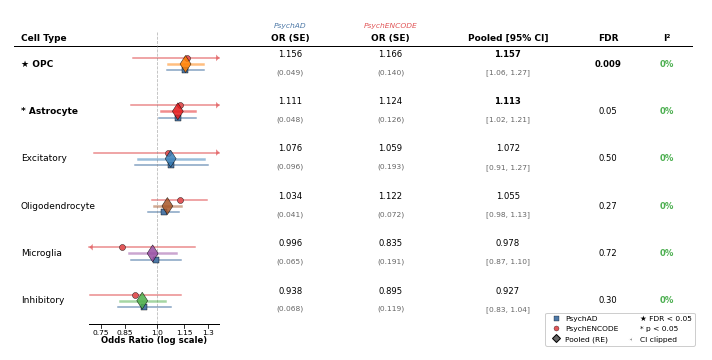


✓ Saved: meta_aging_forest_plot.pdf


In [8]:
# ════════════════════════════════════════════════════════════════════════════════
# FOREST PLOT (TABLE STYLE)
# ════════════════════════════════════════════════════════════════════════════════

print("="*80)
print("FOREST PLOT (TABLE STYLE)")
print("="*80)

from matplotlib.patches import Polygon
from matplotlib.lines import Line2D

# ─────────────────────────────────────────────────────────────────────────────────
# Prepare data
# ─────────────────────────────────────────────────────────────────────────────────

df_plot = df_meta.copy()
df_plot['cohort_ors'] = df_plot['cohort_betas'].apply(lambda bs: [np.exp(b) for b in bs])
df_plot = df_plot.sort_values('pooled_or', ascending=False).reset_index(drop=True)

n_rows = len(df_plot)

print(f"\n  Preparing forest plot for {n_rows} cell types...")

# ─────────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────────

cohort_list = list(COHORTS.keys())
n_cohorts_total = len(cohort_list)

fig_width = 10
row_height = 0.55
fig_height = max(3.5, n_rows * row_height + 1.8)

fig = plt.figure(figsize=(fig_width, fig_height))
ax = fig.add_subplot(111)

# ─────────────────────────────────────────────────────────────────────────────────
# PROPORTIONAL COLUMN SPACING
# ─────────────────────────────────────────────────────────────────────────────────

x_pos = {
    'cell_type': 0.01,
    'forest_left': 0.11,
    'forest_right': 0.30,
}

# Proportional widths for data columns
data_start = 0.33
# Weights: OR(SE) per cohort=3, Pooled=4, FDR=2, I²=1.5
col_weights = [3] * n_cohorts_total + [4, 2, 1.5]
total_weight = sum(col_weights)
data_end = 0.99
data_width = data_end - data_start

cumulative = data_start
col_centers = []
for w in col_weights:
    col_w = (w / total_weight) * data_width
    col_centers.append(cumulative + col_w / 2)
    cumulative += col_w

for i, dataset in enumerate(cohort_list):
    x_pos[dataset] = col_centers[i]

x_pos['pooled'] = col_centers[n_cohorts_total]
x_pos['pvalue'] = col_centers[n_cohorts_total + 1]
x_pos['i2'] = col_centers[n_cohorts_total + 2]

# ─────────────────────────────────────────────────────────────────────────────────
# FONT SIZES
# ─────────────────────────────────────────────────────────────────────────────────

FONT_HEADER = 9
FONT_CELL = 9
FONT_DATA = 8.5
FONT_SMALL = 7.5
FONT_LEGEND = 7.5

# ─────────────────────────────────────────────────────────────────────────────────
# COLORS
# ─────────────────────────────────────────────────────────────────────────────────

META_CT_COLORS = {
    'Astrocyte': '#E41A1C', 'Excitatory': '#377EB8', 'Inhibitory': '#4DAF4A',
    'Microglia': '#984EA3', 'OPC': '#FF7F00', 'Oligodendrocyte': '#A65628',
    'Endothelial': '#F781BF', 'Pericyte': '#999999',
}

cohort_display_names = [COHORTS[ds]['name'] for ds in cohort_list]
COHORT_COLORS_META = dict(zip(cohort_display_names, ['#4E79A7', '#E15759', '#59A14F', '#F28E2B']))

# ─────────────────────────────────────────────────────────────────────────────────
# FOREST PLOT SCALING — with clipping
# ─────────────────────────────────────────────────────────────────────────────────

all_point_estimates = []
for _, row in df_plot.iterrows():
    all_point_estimates.extend(row['cohort_betas'])
    all_point_estimates.append(row['pooled_beta'])

pe_min = min(all_point_estimates)
pe_max = max(all_point_estimates)
pe_range = pe_max - pe_min
padding = max(pe_range * 0.5, 0.15)

log_or_min = pe_min - padding
log_or_max = pe_max + padding

print(f"  Display range: OR [{np.exp(log_or_min):.2f}, {np.exp(log_or_max):.2f}]")

def log_or_to_x(val):
    val_clipped = np.clip(val, log_or_min, log_or_max)
    norm = (val_clipped - log_or_min) / (log_or_max - log_or_min)
    return x_pos['forest_left'] + norm * (x_pos['forest_right'] - x_pos['forest_left'])

def is_clipped_left(val):
    return val < log_or_min

def is_clipped_right(val):
    return val > log_or_max

# ─────────────────────────────────────────────────────────────────────────────────
# HEADERS (tight to first data row)
# ─────────────────────────────────────────────────────────────────────────────────

y_first_row = n_rows - 1
y_headers = y_first_row + 0.45
y_cohort_labels = y_first_row + 0.75
y_header_line = y_headers - 0.08

for dataset in cohort_list:
    display_name = COHORTS[dataset]['name']
    color = COHORT_COLORS_META.get(display_name, '#808080')
    ax.text(x_pos[dataset], y_cohort_labels, display_name,
            fontsize=FONT_SMALL, style='italic', color=color,
            ha='center', va='bottom')

ax.text(x_pos['cell_type'], y_headers, 'Cell Type',
        fontsize=FONT_HEADER, fontweight='bold', ha='left', va='bottom')

for dataset in cohort_list:
    ax.text(x_pos[dataset], y_headers, 'OR (SE)',
            fontsize=FONT_HEADER, fontweight='bold', ha='center', va='bottom')

ax.text(x_pos['pooled'], y_headers, 'Pooled [95% CI]',
        fontsize=FONT_HEADER, fontweight='bold', ha='center', va='bottom')

ax.text(x_pos['pvalue'], y_headers, 'FDR',
        fontsize=FONT_HEADER, fontweight='bold', ha='center', va='bottom')

ax.text(x_pos['i2'], y_headers, 'I²',
        fontsize=FONT_HEADER, fontweight='bold', ha='center', va='bottom')

ax.plot([0, 0.99], [y_header_line, y_header_line], 'k-', lw=1, clip_on=False)

# ─────────────────────────────────────────────────────────────────────────────────
# PLOT ROWS
# ─────────────────────────────────────────────────────────────────────────────────

ARROW_SIZE = 0.005

for idx, (_, row) in enumerate(df_plot.iterrows()):
    y = n_rows - idx - 1

    cell_type = row['Cell_Type']
    is_sig_fdr = row['Significant']
    is_sig_p = row['p_value'] < 0.05

    prefix = ""
    if is_sig_fdr:
        prefix += "★ "
    elif is_sig_p:
        prefix += "* "

    ax.text(x_pos['cell_type'], y, prefix + cell_type,
            fontsize=FONT_CELL,
            fontweight='bold' if is_sig_p else 'normal',
            ha='left', va='center')

    cell_color = META_CT_COLORS.get(cell_type, '#808080')
    cohort_names = row['cohort_names']
    log_ors = row['cohort_betas']
    ses = row['cohort_ses']
    ors = row['cohort_ors']

    offsets = [0] if len(cohort_names) == 1 else [-0.13, 0.13]
    markers = ['s', 'o', '^', 'D']

    for i, (name, log_or, se, or_val, y_off) in enumerate(
            zip(cohort_names, log_ors, ses, ors, offsets)):
        ci_l, ci_h = log_or - 1.96 * se, log_or + 1.96 * se

        x_l = log_or_to_x(ci_l)
        x_h = log_or_to_x(ci_h)
        x_b = log_or_to_x(log_or)

        c_color = COHORT_COLORS_META.get(name, '#808080')
        cohort_idx = next((j for j, ds in enumerate(cohort_list)
                          if COHORTS[ds]['name'] == name), 0)
        marker = markers[cohort_idx % len(markers)]

        ax.plot([x_l, x_h], [y + y_off, y + y_off], color=c_color, lw=1.5, alpha=0.7, zorder=2)

        if is_clipped_left(ci_l):
            arrow = Polygon([[x_l, y + y_off],
                             [x_l + ARROW_SIZE, y + y_off + 0.07],
                             [x_l + ARROW_SIZE, y + y_off - 0.07]],
                            fc=c_color, ec='none', alpha=0.7, zorder=2)
            ax.add_patch(arrow)

        if is_clipped_right(ci_h):
            arrow = Polygon([[x_h, y + y_off],
                             [x_h - ARROW_SIZE, y + y_off + 0.07],
                             [x_h - ARROW_SIZE, y + y_off - 0.07]],
                            fc=c_color, ec='none', alpha=0.7, zorder=2)
            ax.add_patch(arrow)

        ax.plot(x_b, y + y_off, marker, ms=6, color=c_color, mec='black', mew=0.4, zorder=3)

    # Pooled
    re_log_or = row['pooled_beta']
    re_se = row['pooled_se']
    re_l, re_h = re_log_or - 1.96 * re_se, re_log_or + 1.96 * re_se
    x_re = log_or_to_x(re_log_or)
    x_re_l, x_re_h = log_or_to_x(re_l), log_or_to_x(re_h)

    ax.plot([x_re_l, x_re_h], [y, y], color=cell_color, lw=2.5, alpha=0.5, zorder=4)

    if is_clipped_left(re_l):
        arrow = Polygon([[x_re_l, y],
                         [x_re_l + ARROW_SIZE, y + 0.09],
                         [x_re_l + ARROW_SIZE, y - 0.09]],
                        fc=cell_color, ec='none', alpha=0.7, zorder=4)
        ax.add_patch(arrow)

    if is_clipped_right(re_h):
        arrow = Polygon([[x_re_h, y],
                         [x_re_h - ARROW_SIZE, y + 0.09],
                         [x_re_h - ARROW_SIZE, y - 0.09]],
                        fc=cell_color, ec='none', alpha=0.7, zorder=4)
        ax.add_patch(arrow)

    dw, dh = 0.008, 0.18
    diamond = Polygon([[x_re-dw, y], [x_re, y-dh], [x_re+dw, y], [x_re, y+dh]],
                      fc=cell_color, ec='black', lw=0.5, zorder=5, alpha=0.85)
    ax.add_patch(diamond)

    # Data columns
    for dataset in cohort_list:
        display_name = COHORTS[dataset]['name']
        cohort_idx = [i for i, c in enumerate(cohort_names) if display_name == c]

        if cohort_idx:
            i = cohort_idx[0]
            ax.text(x_pos[dataset], y + 0.11, f"{ors[i]:.3f}",
                    fontsize=FONT_DATA, ha='center', va='bottom')
            ax.text(x_pos[dataset], y - 0.11, f"({ses[i]:.3f})",
                    fontsize=FONT_SMALL, ha='center', va='top', color='#666')
        else:
            ax.text(x_pos[dataset], y, '—', fontsize=FONT_DATA, ha='center', va='center', color='#bbb')

    ax.text(x_pos['pooled'], y + 0.11, f"{row['pooled_or']:.3f}",
            fontsize=FONT_DATA, ha='center', va='bottom',
            fontweight='bold' if is_sig_p else 'normal')
    ax.text(x_pos['pooled'], y - 0.11, f"[{row['ci_lower_or']:.2f}, {row['ci_upper_or']:.2f}]",
            fontsize=FONT_SMALL, ha='center', va='top', color='#666')

    p_val = row['p_adj']
    if p_val < 0.001:
        p_txt = f"{p_val:.1e}"
    elif p_val < 0.01:
        p_txt = f"{p_val:.3f}"
    else:
        p_txt = f"{p_val:.2f}"
    ax.text(x_pos['pvalue'], y, p_txt, fontsize=FONT_DATA, ha='center', va='center',
            fontweight='bold' if is_sig_fdr else 'normal')

    if pd.isna(row['I2']):
        i2_txt, i2_color = 'NA', '#aaa'
    else:
        i2 = row['I2']
        i2_txt = f"{i2:.0f}%"
        i2_color = '#4CAF50' if i2 < 25 else '#FFC107' if i2 < 50 else '#FF9800' if i2 < 75 else '#f44336'

    ax.text(x_pos['i2'], y, i2_txt, fontsize=FONT_DATA, ha='center', va='center',
            color=i2_color, fontweight='bold')

# ─────────────────────────────────────────────────────────────────────────────────
# X-AXIS
# ─────────────────────────────────────────────────────────────────────────────────

y_axis = -0.5
ax.plot([x_pos['forest_left'], x_pos['forest_right']], [y_axis, y_axis], 'k-', lw=1)

x_one = log_or_to_x(0)
ax.axvline(x_one, color='#888', linestyle='--', lw=0.8, ymin=0.05, ymax=0.93, alpha=0.6)

or_ticks = [0.75, 0.85, 1.0, 1.15, 1.3]
for or_val in or_ticks:
    log_or_val = np.log(or_val)
    if log_or_min <= log_or_val <= log_or_max:
        x_tick = log_or_to_x(log_or_val)
        ax.plot([x_tick, x_tick], [y_axis, y_axis - 0.08], 'k-', lw=0.8)
        ax.text(x_tick, y_axis - 0.12, f'{or_val}', fontsize=FONT_SMALL, ha='center', va='top')

ax.text((x_pos['forest_left'] + x_pos['forest_right']) / 2, y_axis - 0.4,
        'Odds Ratio (log scale)', fontsize=FONT_DATA, fontweight='bold', ha='center')

# ─────────────────────────────────────────────────────────────────────────────────
# LEGEND
# ─────────────────────────────────────────────────────────────────────────────────

legend_elements = []
markers_leg = ['s', 'o', '^', 'D']

for i, dataset in enumerate(cohort_list):
    display_name = COHORTS[dataset]['name']
    color = COHORT_COLORS_META.get(display_name, '#808080')
    legend_elements.append(Line2D([0], [0], marker=markers_leg[i], color='w',
                                   markerfacecolor=color, markersize=5,
                                   markeredgecolor='black', markeredgewidth=0.3,
                                   label=display_name))

legend_elements.append(Line2D([0], [0], marker='D', color='w', markerfacecolor='#666',
                               markersize=6, markeredgecolor='black', label='Pooled (RE)'))
legend_elements.append(Line2D([0], [0], marker='', color='w', label='★ FDR < 0.05'))
legend_elements.append(Line2D([0], [0], marker='', color='w', label='* p < 0.05'))
legend_elements.append(Line2D([0], [0], marker='<', color='w', markerfacecolor='#999',
                               markersize=4, label='CI clipped'))

ax.legend(handles=legend_elements, loc='lower right', fontsize=FONT_LEGEND,
          frameon=True, framealpha=0.95, edgecolor='#ccc', ncol=2,
          bbox_to_anchor=(0.99, 0.01), handletextpad=0.3, columnspacing=0.5)

# ─────────────────────────────────────────────────────────────────────────────────
# FINAL
# ─────────────────────────────────────────────────────────────────────────────────

ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-1.1, y_cohort_labels + 0.45)
ax.axis('off')

plt.tight_layout()

fig.savefig(FIGURES_DIR / f'meta_{STUDY_TYPE}_forest_plot.pdf', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(FIGURES_DIR / f'meta_{STUDY_TYPE}_forest_plot.svg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✓ Saved: meta_{STUDY_TYPE}_forest_plot.pdf")
print("="*80)

TRAJECTORY PLOT

  Loading donor × cell type data...
    ✓ PsychAD: 744 rows, 6 cell types
      Study groups: ['Age_20_29', 'Age_30_39', 'Age_40_49', 'Age_50_59', 'Age_60_69', 'Age_70_79', 'Age_80_100']
    ✓ PsychENCODE: 414 rows, 6 cell types
      Study groups: ['Age_30_39', 'Age_40_49', 'Age_50_59', 'Age_60_69', 'Age_70_79', 'Age_80_100']

  Combined: 1,158 rows from 2 cohorts
    ✓ Pooled estimates: 42
  Study groups: ['20–29', '30–39', '40–49', '50–59', '60–69', '70–79', '80–100']


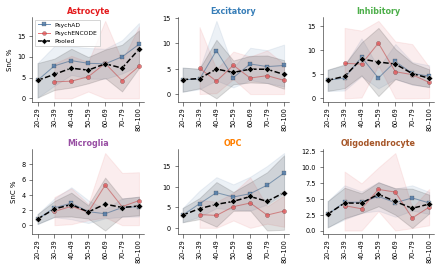


✓ Saved: meta_aging_trajectory.pdf


In [9]:
# ════════════════════════════════════════════════════════════════════════════════
# TRAJECTORY PLOT
# ════════════════════════════════════════════════════════════════════════════════

print("="*70)
print("TRAJECTORY PLOT")
print("="*70)

from matplotlib.lines import Line2D

# ─────────────────────────────────────────────────────────────────────────────────
# Pooling function
# ─────────────────────────────────────────────────────────────────────────────────

def pool_prevalence_re(means, sems):
    means = np.array(means)
    sems = np.array(sems)
    variances = sems ** 2
    
    weights_fixed = 1 / variances
    pooled_fixed = np.sum(weights_fixed * means) / np.sum(weights_fixed)
    
    Q = np.sum(weights_fixed * (means - pooled_fixed) ** 2)
    df = len(means) - 1
    
    C = np.sum(weights_fixed) - np.sum(weights_fixed ** 2) / np.sum(weights_fixed)
    tau2 = max(0, (Q - df) / C) if C > 0 else 0
    
    weights_re = 1 / (variances + tau2)
    pooled = np.sum(weights_re * means) / np.sum(weights_re)
    pooled_se = np.sqrt(1 / np.sum(weights_re))
    
    return {
        'mean': pooled,
        'ci_lower': pooled - 1.96 * pooled_se,
        'ci_upper': pooled + 1.96 * pooled_se,
    }

# ─────────────────────────────────────────────────────────────────────────────────
# Load donor × cell type data
# ─────────────────────────────────────────────────────────────────────────────────

print("\n  Loading donor × cell type data...")

df_traj_list = []

for dataset_key, info in COHORTS.items():
    donor_ct_file = INPUT_DIR / dataset_key / 'data' / f"{dataset_key}_donor_celltype.csv"
    
    if not donor_ct_file.exists():
        print(f"    ✗ {info['name']}: {donor_ct_file} not found")
        continue
    
    df = pd.read_csv(donor_ct_file)
    df['Cohort_Name'] = info['name']
    df['Dataset'] = dataset_key
    
    df['Cell_Type'] = df['Cell_Type'].map(CELL_TYPE_MAP).fillna(df['Cell_Type'])
    df = df[df['Cell_Type'].isin(shared_cts)]
    
    n_before = len(df)
    df = df.dropna(subset=['Study_Group'])
    n_dropped = n_before - len(df)
    
    print(f"    ✓ {info['name']}: {len(df):,} rows, {df['Cell_Type'].nunique()} cell types")
    if n_dropped > 0:
        print(f"      ⚠ Dropped {n_dropped} rows with missing Study_Group")
    print(f"      Study groups: {sorted(df['Study_Group'].unique())}")
    
    df_traj_list.append(df)

if len(df_traj_list) == 0:
    print("\n  ⚠ No donor-level data found. Skipping trajectory plot.")
else:
    df_traj = pd.concat(df_traj_list, ignore_index=True)
    print(f"\n  Combined: {len(df_traj):,} rows from {len(df_traj_list)} cohorts")

    # ─────────────────────────────────────────────────────────────────────────
    # Prevalence per Study_Group × Cell_Type × Cohort
    # ─────────────────────────────────────────────────────────────────────────
    
    df_prev = df_traj.groupby(['Cohort_Name', 'Cell_Type', 'Study_Group']).agg(
        mean_prev=('prop_snc', 'mean'),
        std_prev=('prop_snc', 'std'),
        n_donors=('Donor', 'nunique'),
    ).reset_index()
    
    df_prev['sem'] = (df_prev['std_prev'] / np.sqrt(df_prev['n_donors'])).fillna(0)
    df_prev['ci_lower'] = (df_prev['mean_prev'] - 1.96 * df_prev['sem']).clip(lower=0)
    df_prev['ci_upper'] = df_prev['mean_prev'] + 1.96 * df_prev['sem']
    
    df_prev['mean_pct'] = df_prev['mean_prev'] * 100
    df_prev['ci_lower_pct'] = df_prev['ci_lower'] * 100
    df_prev['ci_upper_pct'] = df_prev['ci_upper'] * 100
    df_prev['sem_pct'] = df_prev['sem'] * 100

    # ─────────────────────────────────────────────────────────────────────────
    # Pooled estimates
    # ─────────────────────────────────────────────────────────────────────────
    
    pooled_results = []
    
    for (cell_type, study_group), group_df in df_prev.groupby(['Cell_Type', 'Study_Group']):
        means = group_df['mean_pct'].values
        sems = np.where(group_df['sem_pct'].values == 0, 0.001, group_df['sem_pct'].values)
        
        if len(means) == 1:
            pooled = {
                'mean': means[0],
                'ci_lower': group_df['ci_lower_pct'].values[0],
                'ci_upper': group_df['ci_upper_pct'].values[0],
            }
        else:
            pooled = pool_prevalence_re(means, sems)
        
        pooled_results.append({
            'Cell_Type': cell_type,
            'Study_Group': study_group,
            'pooled_mean_pct': pooled['mean'],
            'pooled_ci_lower_pct': pooled['ci_lower'],
            'pooled_ci_upper_pct': pooled['ci_upper'],
            'n_cohorts': len(means),
        })
    
    df_pooled = pd.DataFrame(pooled_results)
    print(f"    ✓ Pooled estimates: {len(df_pooled)}")

    # ─────────────────────────────────────────────────────────────────────────
    # Order study groups
    # ─────────────────────────────────────────────────────────────────────────
    
    def get_group_order(sg):
        if pd.isna(sg):
            return 999
        sg = str(sg)
        if 'Age_' in sg or sg.startswith('Age'):
            try:
                parts = sg.replace('Age_', '').replace('Age', '').split('_')
                return int(parts[0])
            except:
                return 500
        disease_order = {
            'control': 10, 'ctrl': 10, 'healthy': 10, 'normal': 10,
            'nci': 20, 'mci': 30, 'ad': 40, 'alzheimer': 40, 'dementia': 40,
        }
        for key, val in disease_order.items():
            if key in sg.lower():
                return val
        return 500
    
    all_groups = sorted(df_prev['Study_Group'].dropna().unique(), key=get_group_order)
    group_to_idx = {g: i for i, g in enumerate(all_groups)}
    
    df_prev['group_order'] = df_prev['Study_Group'].map(group_to_idx)
    df_pooled['group_order'] = df_pooled['Study_Group'].map(group_to_idx)
    
    def format_group_label(sg):
        if pd.isna(sg):
            return 'NA'
        sg = str(sg)
        if 'Age_' in sg:
            parts = sg.replace('Age_', '').split('_')
            if len(parts) >= 2:
                return f"{parts[0]}–{parts[1]}"
        return sg
    
    group_labels = [format_group_label(g) for g in all_groups]
    print(f"  Study groups: {group_labels}")

    # ─────────────────────────────────────────────────────────────────────────
    # Colors and markers
    # ─────────────────────────────────────────────────────────────────────────
    
    COHORT_MARKERS = {}
    marker_list = ['s', 'o', '^', 'D']
    for i, ds in enumerate(cohort_list):
        COHORT_MARKERS[COHORTS[ds]['name']] = marker_list[i % len(marker_list)]
    
    cell_types_to_plot = sorted(shared_cts)

    # ─────────────────────────────────────────────────────────────────────────
    # Plot
    # ─────────────────────────────────────────────────────────────────────────
    
    n_types = len(cell_types_to_plot)
    n_cols = min(3, n_types)
    n_rows_plot = int(np.ceil(n_types / n_cols))
    
    fig_width = n_cols * 2.4
    fig_height = n_rows_plot * 2.0
    
    fig, axes = plt.subplots(n_rows_plot, n_cols, figsize=(fig_width, fig_height), sharey=False)
    if n_types == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    cohort_names = df_prev['Cohort_Name'].unique()
    
    for idx, cell_type in enumerate(cell_types_to_plot):
        ax = axes[idx]
        ct_data = df_prev[df_prev['Cell_Type'] == cell_type]
        ct_pooled = df_pooled[df_pooled['Cell_Type'] == cell_type].sort_values('group_order')
        cell_color = META_CT_COLORS.get(cell_type, '#808080')
        
        # Individual cohorts
        for cohort_name in cohort_names:
            cohort_data = ct_data[ct_data['Cohort_Name'] == cohort_name].sort_values('group_order')
            
            if len(cohort_data) == 0:
                continue
            
            x = cohort_data['group_order'].values
            y = cohort_data['mean_pct'].values
            ci_l = cohort_data['ci_lower_pct'].values
            ci_u = cohort_data['ci_upper_pct'].values
            
            color = COHORT_COLORS_META.get(cohort_name, '#808080')
            marker = COHORT_MARKERS.get(cohort_name, 'o')
            
            ax.fill_between(x, ci_l, ci_u, alpha=0.1, color=color)
            ax.plot(x, y, '-', color=color, lw=1, alpha=0.6)
            ax.scatter(x, y, c=color, s=18, marker=marker,
                      edgecolors='black', linewidths=0.2, zorder=3, alpha=0.8)
        
        # Pooled
        if len(ct_pooled) > 0:
            x_p = ct_pooled['group_order'].values
            y_p = ct_pooled['pooled_mean_pct'].values
            ci_l_p = ct_pooled['pooled_ci_lower_pct'].values
            ci_u_p = ct_pooled['pooled_ci_upper_pct'].values
            
            ax.fill_between(x_p, ci_l_p, ci_u_p, alpha=0.12, color='black', zorder=2)
            ax.plot(x_p, y_p, '--', color='black', lw=1.5, zorder=4)
            ax.scatter(x_p, y_p, c='black', s=22, marker='D',
                      edgecolors='white', linewidths=0.4, zorder=5)
        
        # Formatting
        ax.set_title(cell_type, fontsize=8, fontweight='bold', color=cell_color, pad=3)
        ax.set_xticks(range(len(all_groups)))
        ax.set_xticklabels(group_labels, rotation=90, ha='center', fontsize=6.5)
        ax.tick_params(axis='y', labelsize=6.5)
        ax.tick_params(axis='x', pad=1)
        if idx % n_cols == 0:
            ax.set_ylabel('SnC %', fontsize=7)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(0.5)
        ax.spines['bottom'].set_linewidth(0.5)
    
    for idx in range(n_types, len(axes)):
        axes[idx].axis('off')
    
    # Legend
    legend_elements = []
    for cohort_name in cohort_names:
        color = COHORT_COLORS_META.get(cohort_name, '#808080')
        marker = COHORT_MARKERS.get(cohort_name, 'o')
        legend_elements.append(
            Line2D([0], [0], marker=marker, color=color, lw=1,
                   markerfacecolor=color, markersize=4, markeredgecolor='black',
                   markeredgewidth=0.2, alpha=0.8, label=cohort_name))
    
    legend_elements.append(
        Line2D([0], [0], marker='D', color='black', lw=1.5, ls='--',
               markerfacecolor='black', markersize=4, markeredgecolor='white',
               markeredgewidth=0.3, label='Pooled'))
    
    axes[0].legend(handles=legend_elements, loc='upper left', fontsize=6,
                  frameon=True, fancybox=False, edgecolor='#ccc')
    
    plt.subplots_adjust(hspace=0.55, wspace=0.3)
    
    plt.savefig(FIGURES_DIR / f'meta_{STUDY_TYPE}_trajectory.pdf', dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(FIGURES_DIR / f'meta_{STUDY_TYPE}_trajectory.svg', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    
    print(f"\n✓ Saved: meta_{STUDY_TYPE}_trajectory.pdf")

print("="*70)

TRAJECTORY PLOT

  Loading donor × cell type data...
    ✓ PsychAD: 744 rows, 6 cell types
      Study groups: ['Age_20_29', 'Age_30_39', 'Age_40_49', 'Age_50_59', 'Age_60_69', 'Age_70_79', 'Age_80_100']
    ✓ PsychENCODE: 414 rows, 6 cell types
      Study groups: ['Age_30_39', 'Age_40_49', 'Age_50_59', 'Age_60_69', 'Age_70_79', 'Age_80_100']

  Combined: 1,158 rows from 2 cohorts
    ✓ Pooled estimates: 42
  Study groups: ['20–29', '30–39', '40–49', '50–59', '60–69', '70–79', '80–100']


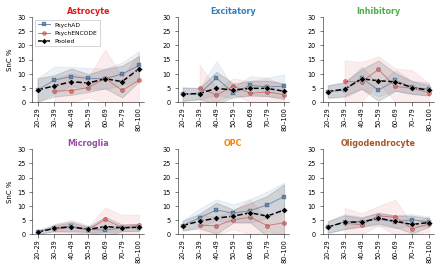


✓ Saved: meta_aging_trajectory.pdf


In [10]:
# ════════════════════════════════════════════════════════════════════════════════
# TRAJECTORY PLOT
# ════════════════════════════════════════════════════════════════════════════════

print("="*70)
print("TRAJECTORY PLOT")
print("="*70)

from matplotlib.lines import Line2D

# ─────────────────────────────────────────────────────────────────────────────────
# Pooling function
# ─────────────────────────────────────────────────────────────────────────────────

def pool_prevalence_re(means, sems):
    means = np.array(means)
    sems = np.array(sems)
    variances = sems ** 2
    
    weights_fixed = 1 / variances
    pooled_fixed = np.sum(weights_fixed * means) / np.sum(weights_fixed)
    
    Q = np.sum(weights_fixed * (means - pooled_fixed) ** 2)
    df = len(means) - 1
    
    C = np.sum(weights_fixed) - np.sum(weights_fixed ** 2) / np.sum(weights_fixed)
    tau2 = max(0, (Q - df) / C) if C > 0 else 0
    
    weights_re = 1 / (variances + tau2)
    pooled = np.sum(weights_re * means) / np.sum(weights_re)
    pooled_se = np.sqrt(1 / np.sum(weights_re))
    
    return {
        'mean': pooled,
        'ci_lower': pooled - 1.96 * pooled_se,
        'ci_upper': pooled + 1.96 * pooled_se,
    }

# ─────────────────────────────────────────────────────────────────────────────────
# Load donor × cell type data
# ─────────────────────────────────────────────────────────────────────────────────

print("\n  Loading donor × cell type data...")

df_traj_list = []

for dataset_key, info in COHORTS.items():
    donor_ct_file = INPUT_DIR / dataset_key / 'data' / f"{dataset_key}_donor_celltype.csv"
    
    if not donor_ct_file.exists():
        print(f"    ✗ {info['name']}: {donor_ct_file} not found")
        continue
    
    df = pd.read_csv(donor_ct_file)
    df['Cohort_Name'] = info['name']
    df['Dataset'] = dataset_key
    
    df['Cell_Type'] = df['Cell_Type'].map(CELL_TYPE_MAP).fillna(df['Cell_Type'])
    df = df[df['Cell_Type'].isin(shared_cts)]
    
    n_before = len(df)
    df = df.dropna(subset=['Study_Group'])
    n_dropped = n_before - len(df)
    
    print(f"    ✓ {info['name']}: {len(df):,} rows, {df['Cell_Type'].nunique()} cell types")
    if n_dropped > 0:
        print(f"      ⚠ Dropped {n_dropped} rows with missing Study_Group")
    print(f"      Study groups: {sorted(df['Study_Group'].unique())}")
    
    df_traj_list.append(df)

if len(df_traj_list) == 0:
    print("\n  ⚠ No donor-level data found. Skipping trajectory plot.")
else:
    df_traj = pd.concat(df_traj_list, ignore_index=True)
    print(f"\n  Combined: {len(df_traj):,} rows from {len(df_traj_list)} cohorts")

    # ─────────────────────────────────────────────────────────────────────────
    # Prevalence per Study_Group × Cell_Type × Cohort
    # ─────────────────────────────────────────────────────────────────────────
    
    df_prev = df_traj.groupby(['Cohort_Name', 'Cell_Type', 'Study_Group']).agg(
        mean_prev=('prop_snc', 'mean'),
        std_prev=('prop_snc', 'std'),
        n_donors=('Donor', 'nunique'),
    ).reset_index()
    
    df_prev['sem'] = (df_prev['std_prev'] / np.sqrt(df_prev['n_donors'])).fillna(0)
    df_prev['ci_lower'] = (df_prev['mean_prev'] - 1.96 * df_prev['sem']).clip(lower=0)
    df_prev['ci_upper'] = df_prev['mean_prev'] + 1.96 * df_prev['sem']
    
    df_prev['mean_pct'] = df_prev['mean_prev'] * 100
    df_prev['ci_lower_pct'] = df_prev['ci_lower'] * 100
    df_prev['ci_upper_pct'] = df_prev['ci_upper'] * 100
    df_prev['sem_pct'] = df_prev['sem'] * 100

    # ─────────────────────────────────────────────────────────────────────────
    # Pooled estimates
    # ─────────────────────────────────────────────────────────────────────────
    
    pooled_results = []
    
    for (cell_type, study_group), group_df in df_prev.groupby(['Cell_Type', 'Study_Group']):
        means = group_df['mean_pct'].values
        sems = np.where(group_df['sem_pct'].values == 0, 0.001, group_df['sem_pct'].values)
        
        if len(means) == 1:
            pooled = {
                'mean': means[0],
                'ci_lower': group_df['ci_lower_pct'].values[0],
                'ci_upper': group_df['ci_upper_pct'].values[0],
            }
        else:
            pooled = pool_prevalence_re(means, sems)
        
        pooled_results.append({
            'Cell_Type': cell_type,
            'Study_Group': study_group,
            'pooled_mean_pct': pooled['mean'],
            'pooled_ci_lower_pct': pooled['ci_lower'],
            'pooled_ci_upper_pct': pooled['ci_upper'],
            'n_cohorts': len(means),
        })
    
    df_pooled = pd.DataFrame(pooled_results)
    print(f"    ✓ Pooled estimates: {len(df_pooled)}")

    # ─────────────────────────────────────────────────────────────────────────
    # Order study groups
    # ─────────────────────────────────────────────────────────────────────────
    
    def get_group_order(sg):
        if pd.isna(sg):
            return 999
        sg = str(sg)
        if 'Age_' in sg or sg.startswith('Age'):
            try:
                parts = sg.replace('Age_', '').replace('Age', '').split('_')
                return int(parts[0])
            except:
                return 500
        disease_order = {
            'control': 10, 'ctrl': 10, 'healthy': 10, 'normal': 10,
            'nci': 20, 'mci': 30, 'ad': 40, 'alzheimer': 40, 'dementia': 40,
        }
        for key, val in disease_order.items():
            if key in sg.lower():
                return val
        return 500
    
    all_groups = sorted(df_prev['Study_Group'].dropna().unique(), key=get_group_order)
    group_to_idx = {g: i for i, g in enumerate(all_groups)}
    
    df_prev['group_order'] = df_prev['Study_Group'].map(group_to_idx)
    df_pooled['group_order'] = df_pooled['Study_Group'].map(group_to_idx)
    
    def format_group_label(sg):
        if pd.isna(sg):
            return 'NA'
        sg = str(sg)
        if 'Age_' in sg:
            parts = sg.replace('Age_', '').split('_')
            if len(parts) >= 2:
                return f"{parts[0]}–{parts[1]}"
        return sg
    
    group_labels = [format_group_label(g) for g in all_groups]
    print(f"  Study groups: {group_labels}")

    # ─────────────────────────────────────────────────────────────────────────
    # Colors and markers
    # ─────────────────────────────────────────────────────────────────────────
    
    COHORT_MARKERS = {}
    marker_list = ['s', 'o', '^', 'D']
    for i, ds in enumerate(cohort_list):
        COHORT_MARKERS[COHORTS[ds]['name']] = marker_list[i % len(marker_list)]
    
    cell_types_to_plot = sorted(shared_cts)

    # ─────────────────────────────────────────────────────────────────────────
    # Plot
    # ─────────────────────────────────────────────────────────────────────────
    
    n_types = len(cell_types_to_plot)
    n_cols = min(3, n_types)
    n_rows_plot = int(np.ceil(n_types / n_cols))
    
    fig_width = n_cols * 2.4
    fig_height = n_rows_plot * 2.0
    
    fig, axes = plt.subplots(n_rows_plot, n_cols, figsize=(fig_width, fig_height), sharey=False)
    if n_types == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    cohort_names = df_prev['Cohort_Name'].unique()
    
    for idx, cell_type in enumerate(cell_types_to_plot):
        ax = axes[idx]
        ct_data = df_prev[df_prev['Cell_Type'] == cell_type]
        ct_pooled = df_pooled[df_pooled['Cell_Type'] == cell_type].sort_values('group_order')
        cell_color = META_CT_COLORS.get(cell_type, '#808080')
        
        # Individual cohorts
        for cohort_name in cohort_names:
            cohort_data = ct_data[ct_data['Cohort_Name'] == cohort_name].sort_values('group_order')
            
            if len(cohort_data) == 0:
                continue
            
            x = cohort_data['group_order'].values
            y = cohort_data['mean_pct'].values
            ci_l = cohort_data['ci_lower_pct'].values
            ci_u = cohort_data['ci_upper_pct'].values
            
            color = COHORT_COLORS_META.get(cohort_name, '#808080')
            marker = COHORT_MARKERS.get(cohort_name, 'o')
            
            ax.fill_between(x, ci_l, ci_u, alpha=0.1, color=color)
            ax.plot(x, y, '-', color=color, lw=1, alpha=0.6)
            ax.scatter(x, y, c=color, s=18, marker=marker,
                      edgecolors='black', linewidths=0.2, zorder=3, alpha=0.8)
        
        # Pooled
        if len(ct_pooled) > 0:
            x_p = ct_pooled['group_order'].values
            y_p = ct_pooled['pooled_mean_pct'].values
            ci_l_p = ct_pooled['pooled_ci_lower_pct'].values
            ci_u_p = ct_pooled['pooled_ci_upper_pct'].values
            
            ax.fill_between(x_p, ci_l_p, ci_u_p, alpha=0.12, color='black', zorder=2)
            ax.plot(x_p, y_p, '--', color='black', lw=1.5, zorder=4)
            ax.scatter(x_p, y_p, c='black', s=22, marker='D',
                      edgecolors='white', linewidths=0.4, zorder=5)
        
        # Formatting
        ax.set_ylim(0, 30)
        ax.set_title(cell_type, fontsize=8, fontweight='bold', color=cell_color, pad=3)
        ax.set_xticks(range(len(all_groups)))
        ax.set_xticklabels(group_labels, rotation=90, ha='center', fontsize=6.5)
        ax.tick_params(axis='y', labelsize=6.5)
        ax.tick_params(axis='x', pad=1)
        if idx % n_cols == 0:
            ax.set_ylabel('SnC %', fontsize=7)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(0.5)
        ax.spines['bottom'].set_linewidth(0.5)
    
    for idx in range(n_types, len(axes)):
        axes[idx].axis('off')
    
    # Legend
    legend_elements = []
    for cohort_name in cohort_names:
        color = COHORT_COLORS_META.get(cohort_name, '#808080')
        marker = COHORT_MARKERS.get(cohort_name, 'o')
        legend_elements.append(
            Line2D([0], [0], marker=marker, color=color, lw=1,
                   markerfacecolor=color, markersize=4, markeredgecolor='black',
                   markeredgewidth=0.2, alpha=0.8, label=cohort_name))
    
    legend_elements.append(
        Line2D([0], [0], marker='D', color='black', lw=1.5, ls='--',
               markerfacecolor='black', markersize=4, markeredgecolor='white',
               markeredgewidth=0.3, label='Pooled'))
    
    axes[0].legend(handles=legend_elements, loc='upper left', fontsize=6,
                  frameon=True, fancybox=False, edgecolor='#ccc')
    
    plt.subplots_adjust(hspace=0.55, wspace=0.3)
    
    plt.savefig(FIGURES_DIR / f'meta_{STUDY_TYPE}_trajectory.pdf', dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(FIGURES_DIR / f'meta_{STUDY_TYPE}_trajectory.svg', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    
    print(f"\n✓ Saved: meta_{STUDY_TYPE}_trajectory.pdf")

print("="*70)

In [11]:
# ════════════════════════════════════════════════════════════════════════════════
# EXPORT
# ════════════════════════════════════════════════════════════════════════════════

print("="*60)
print("EXPORT")
print("="*60)

# ─────────────────────────────────────────────────────────────────────────────────
# Meta-analysis results
# ─────────────────────────────────────────────────────────────────────────────────

export_cols = ['Cell_Type', 'k', 'is_shared', 'cohorts',
               'pooled_beta', 'pooled_se', 'pooled_or',
               'ci_lower_or', 'ci_upper_or',
               'p_value', 'p_adj', 'Significant',
               'I2', 'Q', 'Q_p', 'tau2', 'method']

df_export = df_meta[export_cols].sort_values('p_adj')
df_export.to_csv(RESULTS_DIR / f'meta_{STUDY_TYPE}_results.csv', index=False)

print(f"\n✓ Saved: meta_{STUDY_TYPE}_results.csv")
print(f"  Cell types: {len(df_export)}")
print(f"  Significant: {df_export['Significant'].sum()}")

# ─────────────────────────────────────────────────────────────────────────────────
# Trajectory pooled prevalence
# ─────────────────────────────────────────────────────────────────────────────────

if 'df_pooled' in dir() and len(df_pooled) > 0:
    df_pooled_export = df_pooled.sort_values(['Cell_Type', 'group_order'])
    df_pooled_export.to_csv(RESULTS_DIR / f'meta_{STUDY_TYPE}_trajectory_prevalence.csv', index=False)
    print(f"✓ Saved: meta_{STUDY_TYPE}_trajectory_prevalence.csv")
    print(f"  Rows: {len(df_pooled_export)} (Cell_Type × Study_Group)")

# ─────────────────────────────────────────────────────────────────────────────────
# Interpretation
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("INTERPRETATION")
print(f"{'─'*60}")

sig_results = df_export[df_export['Significant']]

if len(sig_results) > 0:
    sig_up = sig_results[sig_results['pooled_or'] > 1]
    sig_down = sig_results[sig_results['pooled_or'] < 1]
    
    if len(sig_up) > 0:
        print(f"\n▸ Increased senescence with {STUDY_TYPE}:")
        for _, row in sig_up.iterrows():
            pct_change = (row['pooled_or'] - 1) * 100
            print(f"  {row['Cell_Type']}: OR={row['pooled_or']:.3f} "
                  f"[{row['ci_lower_or']:.2f}, {row['ci_upper_or']:.2f}], "
                  f"+{pct_change:.1f}%/decade, FDR={row['p_adj']:.2e}")
    
    if len(sig_down) > 0:
        print(f"\n▸ Decreased senescence with {STUDY_TYPE}:")
        for _, row in sig_down.iterrows():
            pct_change = (1 - row['pooled_or']) * 100
            print(f"  {row['Cell_Type']}: OR={row['pooled_or']:.3f} "
                  f"[{row['ci_lower_or']:.2f}, {row['ci_upper_or']:.2f}], "
                  f"-{pct_change:.1f}%/decade, FDR={row['p_adj']:.2e}")
else:
    print("\n▸ No significant pooled associations")

# ─────────────────────────────────────────────────────────────────────────────────
# Summary
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("SUMMARY")
print(f"{'─'*60}")

print(f"\n▸ Study type: {STUDY_TYPE}")
print(f"  Cohorts: {', '.join([COHORTS[ds]['name'] for ds in cohort_list])}")
print(f"  Shared cell types: {len(shared_cts)}")
print(f"  Method: Random-effects (DerSimonian-Laird)")
print(f"  FDR correction: Benjamini-Hochberg")

print(f"\n▸ Results:")
print(f"  Significant (FDR<0.05): {df_export['Significant'].sum()} / {len(df_export)}")
print(f"  OR range: {df_export['pooled_or'].min():.3f} – {df_export['pooled_or'].max():.3f}")
if 'I2' in df_export.columns:
    i2_vals = df_export['I2'].dropna()
    if len(i2_vals) > 0:
        print(f"  I² range: {i2_vals.min():.0f}% – {i2_vals.max():.0f}%")

print(f"\n▸ Outputs:")
print(f"  {RESULTS_DIR / f'meta_{STUDY_TYPE}_results.csv'}")
if 'df_pooled' in dir():
    print(f"  {RESULTS_DIR / f'meta_{STUDY_TYPE}_trajectory_prevalence.csv'}")
print(f"  {FIGURES_DIR / f'meta_{STUDY_TYPE}_forest_plot.pdf'}")
print(f"  {FIGURES_DIR / f'meta_{STUDY_TYPE}_trajectory.pdf'}")

print("\n" + "="*60)
print("✓ MODULE 03 COMPLETE")
print("="*60)

EXPORT

✓ Saved: meta_aging_results.csv
  Cell types: 6
  Significant: 1
✓ Saved: meta_aging_trajectory_prevalence.csv
  Rows: 42 (Cell_Type × Study_Group)

────────────────────────────────────────────────────────────
INTERPRETATION
────────────────────────────────────────────────────────────

▸ Increased senescence with aging:
  OPC: OR=1.157 [1.06, 1.27], +15.7%/decade, FDR=8.85e-03

────────────────────────────────────────────────────────────
SUMMARY
────────────────────────────────────────────────────────────

▸ Study type: aging
  Cohorts: PsychAD, PsychENCODE
  Shared cell types: 6
  Method: Random-effects (DerSimonian-Laird)
  FDR correction: Benjamini-Hochberg

▸ Results:
  Significant (FDR<0.05): 1 / 6
  OR range: 0.927 – 1.157
  I² range: 0% – 0%

▸ Outputs:
  /fs/scratch/PAS2598/senescence_analysis/results/03_meta_analysis/aging/meta_aging_results.csv
  /fs/scratch/PAS2598/senescence_analysis/results/03_meta_analysis/aging/meta_aging_trajectory_prevalence.csv
  /fs/scratch/P